In [2]:
import sys
!{sys.executable} -m pip install torch matplotlib scikit-learn numpy --q

Epoch 50 | Loss: 0.0008
Epoch 100 | Loss: 0.0005
Epoch 150 | Loss: 0.0004


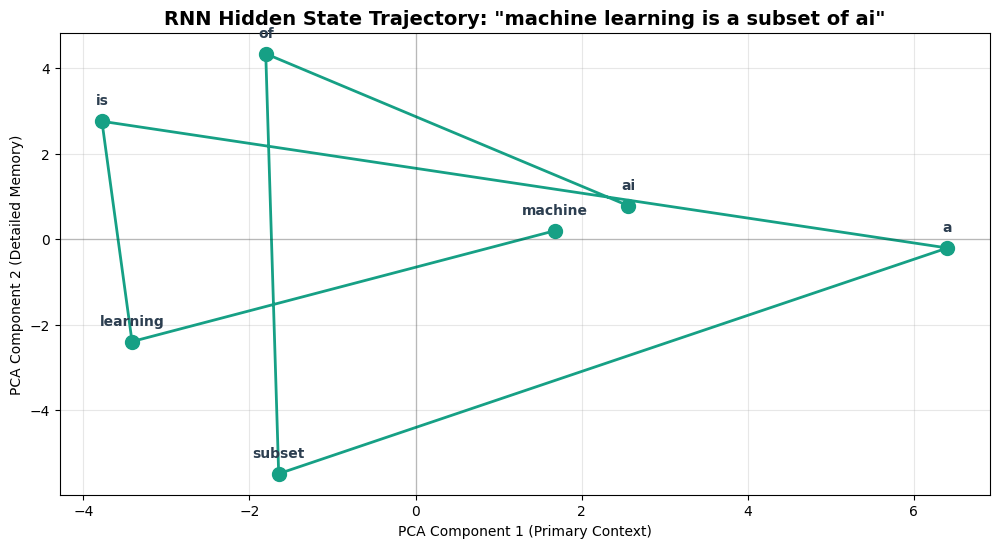

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- 1. Dataset with Varied Sentence Lengths ---
sentences = [
    "artificial intelligence is the future",
    "machine learning is a subset of ai",
    "deep learning use neural networks",
    "neural networks mimic the human brain"
]

# Vocabulary setup with <PAD> token at index 0
words = " ".join(sentences).lower().split()
vocab = ["<PAD>"] + sorted(list(set(words)))
word_to_ix = {w: i for i, w in enumerate(vocab)}
ix_to_word = {i: word for i, word in enumerate(vocab)}
vocab_size = len(vocab)
max_len = max(len(s.split()) for s in sentences)

# Padding logic to ensure uniform tensor shapes
def get_padded_tensors(sentence_list):
    padded_ids = []
    for s in sentence_list:
        ids = [word_to_ix[w] for w in s.lower().split()]
        ids += [0] * (max_len - len(ids)) # Add PAD tokens
        padded_ids.append(ids)
    return torch.LongTensor(padded_ids)

X_train = get_padded_tensors(sentences)
# Target is the next word (shifted X)
Y_train = torch.roll(X_train, shifts=-1, dims=1)

# --- 2. RNN Model Architecture ---
class HiddenRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(HiddenRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        embeds = self.embedding(x)
        h_states, _ = self.rnn(embeds) # h_states contains memory for each time step
        out = self.fc(h_states)
        return out, h_states

# --- 3. Training Loop ---
HIDDEN_DIM = 64
model = HiddenRNN(vocab_size, 32, HIDDEN_DIM)
criterion = nn.CrossEntropyLoss(ignore_index=0) # Ignore <PAD> in loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

model.train()
for epoch in range(150):
    optimizer.zero_grad()
    outputs, _ = model(X_train)
    loss = criterion(outputs.view(-1, vocab_size), Y_train.view(-1))
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

# --- 4. Hidden State Extraction & Interpretation ---
test_sentence = "machine learning is a subset of ai"
test_tokens = test_sentence.lower().split()
test_input = torch.LongTensor([[word_to_ix[w] for w in test_tokens]])

model.eval()
with torch.no_grad():
    _, h_states = model(test_input)

# Dimensionality Reduction (32D Hidden State -> 2D Plot)
hidden_matrix = h_states.squeeze(0).numpy()
pca = PCA(n_components=2)
coords = pca.fit_transform(hidden_matrix)

# --- 5. Visualization ---
plt.figure(figsize=(12, 6))
plt.plot(coords[:, 0], coords[:, 1], '-o', color='#16a085', lw=2, markersize=10)

# Annotating the "Learning Path"
for i, txt in enumerate(test_tokens):
    plt.annotate(txt, (coords[i, 0], coords[i, 1]), 
                 textcoords="offset points", xytext=(0,12), 
                 ha='center', fontweight='bold', color='#2c3e50')

plt.title(f'RNN Hidden State Trajectory: "{test_sentence}"', fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1 (Primary Context)')
plt.ylabel('PCA Component 2 (Detailed Memory)')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', lw=1, alpha=0.2)
plt.axvline(0, color='black', lw=1, alpha=0.2)
plt.show()